# Подготовительные операции

Код подготовки рабочего окружения:

In [2]:
# Окружение Python на Kaggle уже содержит множество нужных пакетов в соответствии с образом github.com/kaggle/docker-python

# Собственно PyTorch
import torch

# Готовые блоки для построения нейронных сетей
import torch.nn as nn
import torch.nn.functional as F

# Оптимизаторы - алгоритмы, созданные для ускорения и повышения эффективности градиентного спуска
import torch.optim as optim

# Доступ к готовым наборам данных, в том числе к MNIST
from torchvision import datasets

# Преобразования. Пока нам понадобится только ToTensor()
from torchvision import transforms

# Объединение данных в пакеты (батчи), перемешивание данных при обучении, параллельная загрузка данных
from torch.utils.data import DataLoader

# Matplotlib. Тоже визуализация
import matplotlib.pyplot as plt

# Вспомогательный функционал
import os
import time
import datetime

# Прогресс-бар
import tqdm

import warnings
# Убираем предупреждение о необходимости соответствия аппаратного обеспечения и ПО
warnings.filterwarnings('ignore', category=UserWarning)
# Убираем предупреждение о необходимости актуализации методов
warnings.filterwarnings('ignore', category=DeprecationWarning)
# Можно использовать просто warnings.filterwarnings('ignore'), без уточнения категории,
# но это не очень хорошая практика, которая может привести к плохо уловимым ошибкам в коде

# torchviz не входит в стандартный набор пакетов Kaggle, поэтому нам нужно использовать директиву "%pip install"
%pip install torchviz
# Визуализация структуры нейросетей
from torchviz import make_dot

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Это стандартная мантра Kaggle, напоминающая о некоторых ограничениях при работе на сайте
# Write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# Write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Input data files are available in the read-only "../input/" directory

# Проверяем наличие датасета MNIST
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

## Конфигурация видеокарты

Попробуем:

In [4]:
print(torch.cuda.is_available())

# Характеристики GPU
if torch.cuda.is_available():
    print(torch.cuda.device_count())
    print(torch.cuda.current_device())
    print(torch.cuda.device(torch.cuda.current_device()))
    print(torch.cuda.get_device_name(0))

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu'
print(f'Using {device} device')

True
1
0
NVIDIA GeForce RTX 4060
Using cuda device


## Загрузка датасетов

In [5]:
# Можете попробовать еще transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
# с использованием предварительно рассчитанных для MNIST констант (https://discuss.pytorch.org/t/normalization-in-the-mnist-example/457)
transform = transforms.ToTensor()

# Тренировочный датасет
train_data = datasets.MNIST(root='data', train=True, download=True, transform=transform)

# Тестовый датасет
test_data = datasets.MNIST(root='data', train=False, download=True, transform=transform)

# Чем больше batch_size, тем быстрее идёт процесс обучения, но тем хуже обратная связь, потому что
# реже запускается процесс обратного распространения ошибки
# shuffle=True -> данные будут подаваться в разной последовательности. Полезно для обучения
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)

# batch_size можно и побольше, на точность уже не влияет
test_loader = DataLoader(test_data, batch_size=256, shuffle=False)

print(f"Train: {len(train_data)}, Test: {len(test_data)}")

Train: 60000, Test: 10000


# CNN на одиночном GPU

## Код CNN

In [6]:
class CNN_Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(32 * 5 * 5, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.net(x)

# Не забываем использовать GPU
model = CNN_Net().to(device)

print(f"\nModel structure: {model}\n\n")

# Если хотите посмотреть, что у модели внутри, раскомментируйте код ниже
# for name, param in model.named_parameters():
#    print(f"Layer: {name} Size: {param.size()}  Values: {param[:2]} \n")


Model structure: CNN_Net(
  (net): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=800, out_features=128, bias=True)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=10, bias=True)
  )
)




## Визуализация модели

Визуализация модели при помощи [PyTorchViz](https://github.com/szagoruyko/pytorchviz).

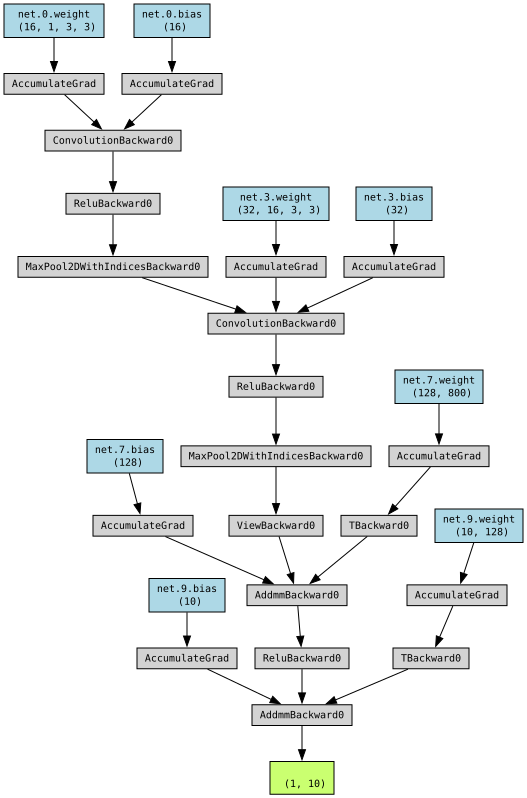

In [7]:
# Закидываем в нашу нейронную сеть тестовый тензор, чтобы PyTorchViz мог проанализировать её внутреннее устройство
x = torch.randn(1, 1, 28, 28).to(device)

make_dot(model(x), params=dict(model.named_parameters()))

## Настройка CNN

Выбираем функцию потерь:

In [8]:
criterion = nn.CrossEntropyLoss()

Выбираем функцию оптимизации:

In [9]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)

## Тренировка CNN

In [10]:
# Количество эпох
n_epochs = 32

# Пустой список для будущего графика
train_loss_curve = []

def model_train():
    # Включение специфических слоёв (Dropout, BatchNorm), используемых только во время обучения. Даже если таких слои отсутствуют,
    # всё равно используйте model.train(), чтобы потом, при их добавлении, не искать ошибки
    model.train()

    # Замеряем продолжительность обучения
    start = time.time()

    # Создаем прогресс-бар
    pbar = tqdm.tqdm(range(1, n_epochs + 1))

    for epoch in pbar:
        train_loss = 0.0  # Мониторим ошибку

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # Очистка старых градиентов. Можно работать и с накоплением градиентов, но этот трюк не для данной (стандартной) ситуации
            optimizer.zero_grad()

            # Прямой проход, модель обсчитывает данные с использованием текущих параметров
            outputs = model(images)

            # Рассчитываем ошибку
            loss = criterion(outputs, labels)

            # Вычисление новых градиентов. Под капотом: обратное распространение ошибки = вычисление частных производных по каждому параметру
            loss.backward()

            # Обновление всех весов модели
            optimizer.step()
            train_loss += loss.item() * images.size(0)

        # Считаем среднюю ошибку за эпоху
        train_loss = train_loss/len(train_loader.dataset)
        train_loss_curve.append(train_loss)
        pbar.set_description(f'Epoch {epoch}  \tTraining Loss: {train_loss:.4f}')

    end = time.time()
    print(f"\nElapsed time: {str(datetime.timedelta(seconds=round(end-start)))}")

model_train()

Epoch 32  	Training Loss: 0.0030: 100%|██████████| 32/32 [04:32<00:00,  8.52s/it]


Elapsed time: 0:04:33


## График ошибки CNN

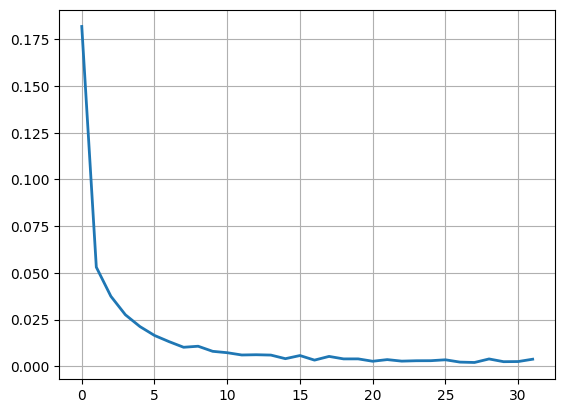

In [10]:
plt.plot(train_loss_curve, linewidth=2)
plt.grid(True)
plt.show()